In [ ]:
!pip install opencv-python numpy matplotlib

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!gdown --id 1BjMpOuuOieJbu5P_jiY2EZVitQUmAHSw -O /content/image.jpg
!gdown --id 1ogUtdr8XtrxFpOa4iD6_AdmMyFlCzIqk -O /content/image2.jpg

/usr/local/lib/python3.13/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1BjMpOuuOieJbu5P_jiY2EZVitQUmAHSw
To: /content/image.jpg
100% 23.8k/23.8k [00:00<00:00, 39.2MB/s]
/usr/local/lib/python3.13/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1ogUtdr8XtrxFpOa4iD6_AdmMyFlCzIqk
To: /content/image2.jpg
100% 191k/191k [00:00<00:00, 26.9MB/s]


Kênh R: TB = 115.1, độ lệch chuẩn = 82.9
Kênh G: TB = 185.1, độ lệch chuẩn = 58.0
Kênh B: TB = 244.8, độ lệch chuẩn = 15.6


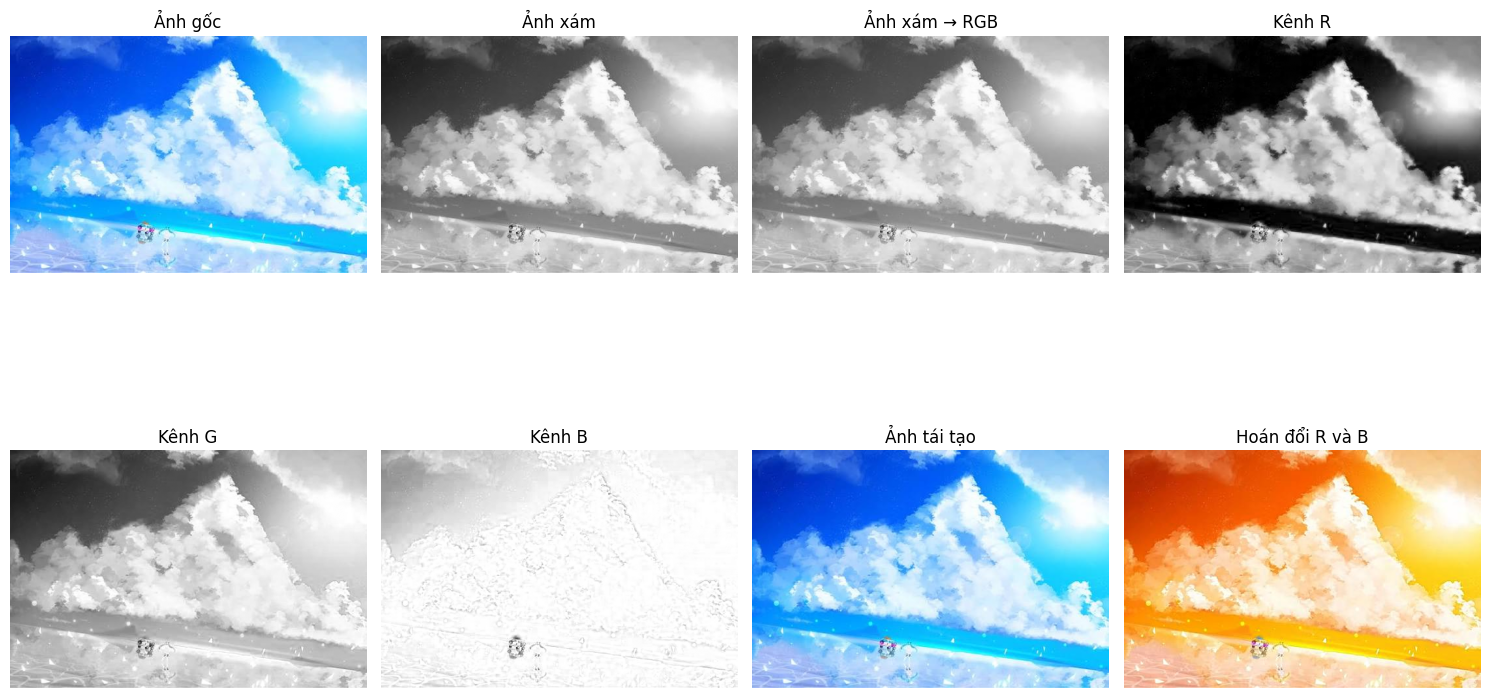

Kênh R: TB = 56.6, độ lệch chuẩn = 58.1
Kênh G: TB = 98.2, độ lệch chuẩn = 39.2
Kênh B: TB = 118.3, độ lệch chuẩn = 46.1


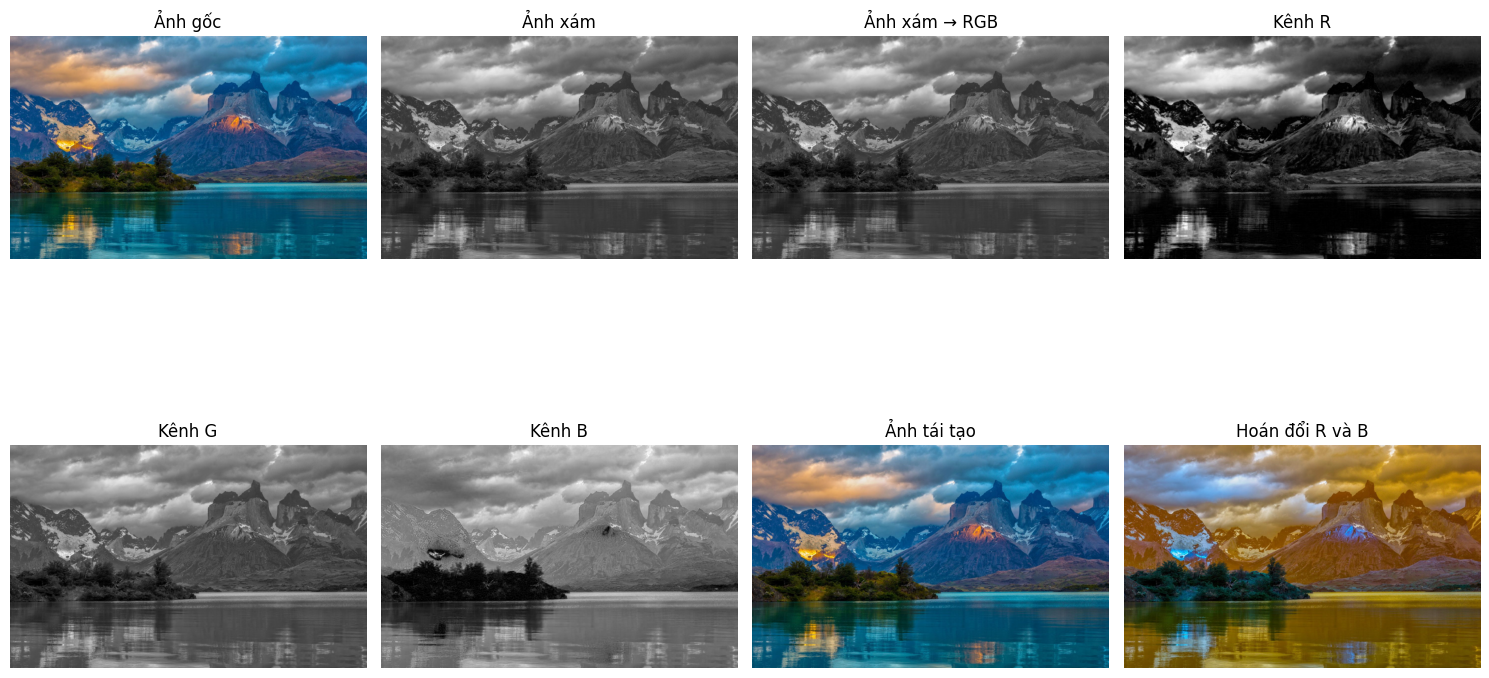

In [ ]:
import cv2
import matplotlib.pyplot as plt

def part1(img, save_path=None):
  if img is None:
    print("Lỗi: Sai đường dẫn")

  img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) #chuyển sang RGB
  gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY) #chuyển sang xám
  img_rgb2 = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB) #chuyển lại sang RGB
  R = img_rgb[..., 0] #lấy kênh R
  G = img_rgb[..., 1] #lấy kênh G
  B = img_rgb[..., 2] #lấy kênh B
  # In giá trị trung bình và độ lệch chuẩn từng kênh
  for name, ch in (("R", R), ("G", G), ("B", B)):
    print(f"Kênh {name}: TB = {ch.mean():.1f}, độ lệch chuẩn = {ch.std():.1f}")
  img_reconstructed = cv2.merge((R, G, B)) #ghép lại 3 kênh
  img_swapped = cv2.merge((B, G, R)) #hoán đổi kênh R và B

  # Hiển thị các ảnh
  plt.figure(figsize=(15, 10))

  # Ảnh gốc
  plt.subplot(2, 4, 1)
  plt.imshow(img_rgb)
  plt.title("Ảnh gốc")
  plt.axis("off")

  # Ảnh xám
  plt.subplot(2, 4, 2)
  plt.imshow(gray, cmap="gray")
  plt.title("Ảnh xám")
  plt.axis("off")

  # Ảnh xám chuyển lại RGB
  plt.subplot(2, 4, 3)
  plt.imshow(img_rgb2)
  plt.title("Ảnh xám → RGB")
  plt.axis("off")

  # Kênh R
  plt.subplot(2, 4, 4)
  plt.imshow(R, cmap="gray")
  plt.title("Kênh R")
  plt.axis("off")

  # Kênh G
  plt.subplot(2, 4, 5)
  plt.imshow(G, cmap="gray")
  plt.title("Kênh G")
  plt.axis("off")

  # Kênh B
  plt.subplot(2, 4, 6)
  plt.imshow(B, cmap="gray")
  plt.title("Kênh B")
  plt.axis("off")

  # Ảnh tái tạo
  plt.subplot(2, 4, 7)
  plt.imshow(img_reconstructed)
  plt.title("Ảnh tái tạo")
  plt.axis("off")

  # Ảnh hoán đổi R và B
  plt.subplot(2, 4, 8)
  plt.imshow(img_swapped)
  plt.title("Hoán đổi R và B")
  plt.axis("off")

  plt.tight_layout()
  if save_path:
    plt.savefig(save_path, dpi=150) #lưu ảnh kết quả
  plt.show()

# Xử lý lần lượt từng ảnh đầu vào
inputs = [
  ("/content/image.jpg", "/content/image_result1.jpg"), #ảnh 1: bầu trời, mây, mặt nước
  ("/content/image2.jpg", "/content/image_result2.jpg"), #ảnh 2: núi, mây, hồ
]
for path, out in inputs:
  img = cv2.imread(path) #đọc theo thứ tự BGR
  part1(img, out)